Shape : (4213, 21)
   temperature_2_m_above_gnd  relative_humidity_2_m_above_gnd  \
0                       2.17                               31   
1                       2.31                               27   
2                       3.65                               33   
3                       5.82                               30   
4                       7.73                               27   

   mean_sea_level_pressure_MSL  total_precipitation_sfc  snowfall_amount_sfc  \
0                       1035.0                      0.0                  0.0   
1                       1035.1                      0.0                  0.0   
2                       1035.4                      0.0                  0.0   
3                       1035.4                      0.0                  0.0   
4                       1034.4                      0.0                  0.0   

   total_cloud_cover_sfc  high_cloud_cover_high_cld_lay  \
0                    0.0                          

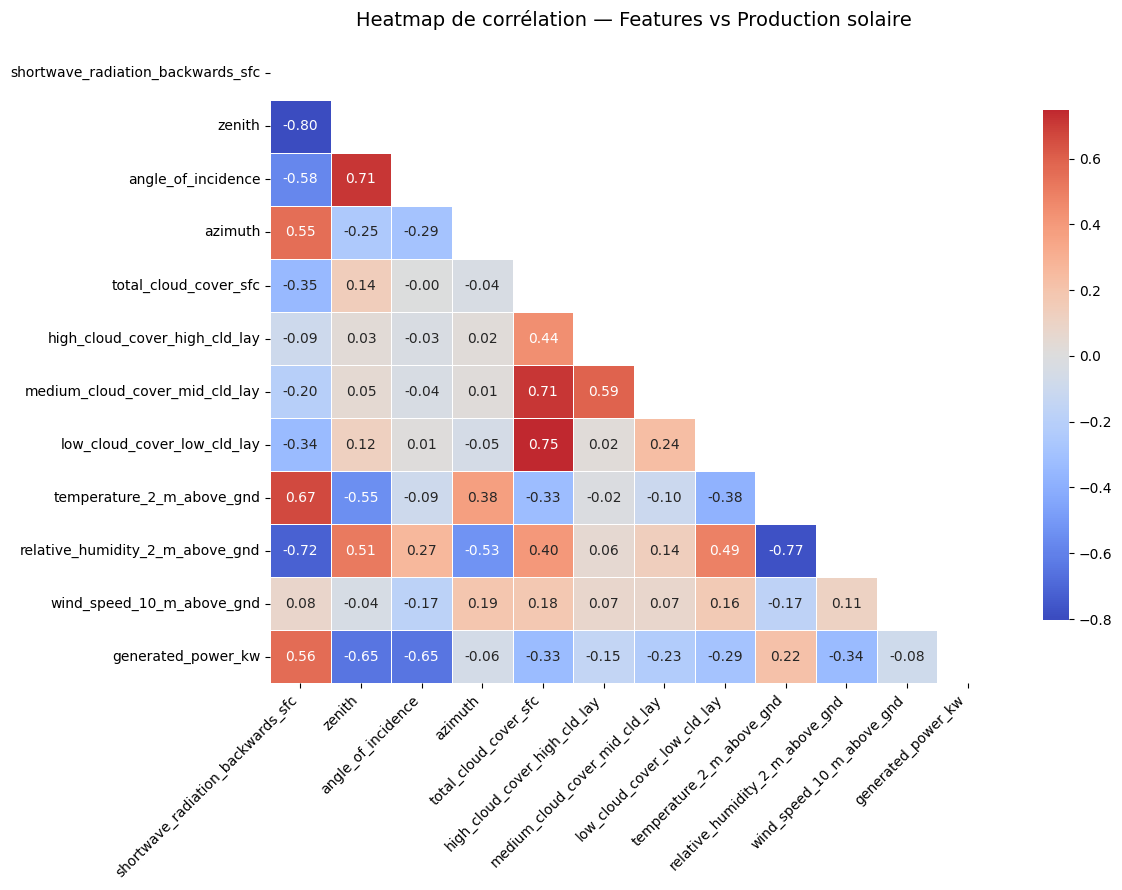

→ Heatmap sauvegardée.
── Split ALÉATOIRE ──
  R² train  : 0.9454
  R² test   : 0.8015
  MAE test  : 268.83 kW
  RMSE test : 425.79 kW
── Split CHRONOLOGIQUE ──
  R² train  : 0.9481
  R² test   : 0.5170
  MAE test  : 489.85 kW
  RMSE test : 631.30 kW


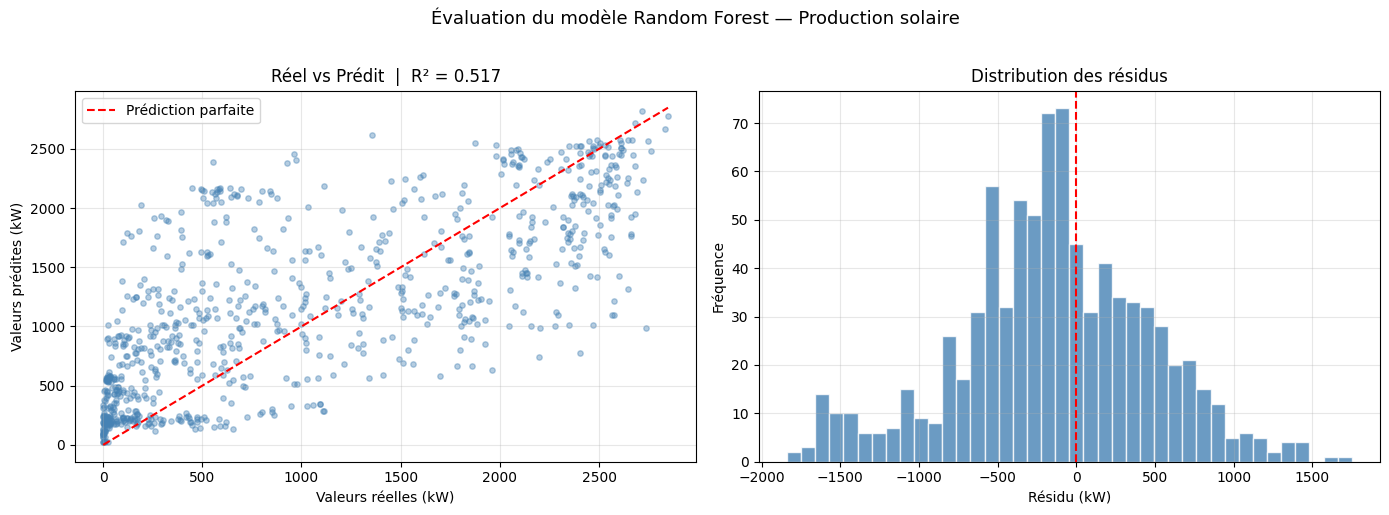

→ Graphiques d'évaluation sauvegardés.


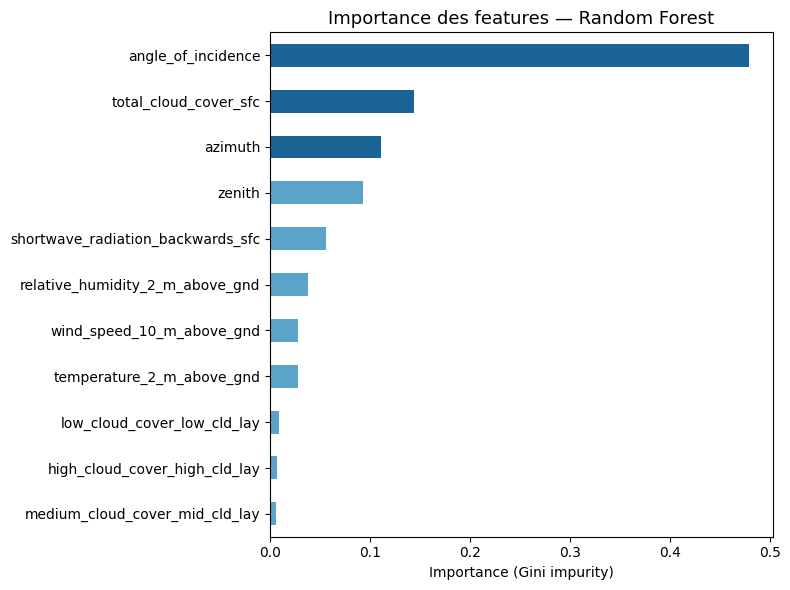

→ Feature importances sauvegardées.

── Auto-test : prédiction sur données fictives ──
  Conditions : bon ensoleillement, ciel dégagé, 20°C
  → Production prédite : 2207.10 kW

  Conditions : ciel couvert (90%), faible rayonnement
  → Production prédite : 1804.28 kW

  ✓ Logique validée : production plus faible par temps couvert.
OK — 300 points | R² = 0.517


In [4]:
# ============================================================
#  SOLAR ENERGY PREDICTION — Kaggle Notebook
#  Auteur : Wael WADIH | CY Tech
# ============================================================

# 0 - IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import warnings
# warnings.filterwarnings("ignore")

# 1 - CHARGEMENT DES DONNÉES 
df = pd.read_csv("/kaggle/input/datasets/stucom/solar-energy-power-generation-dataset/spg.csv")
TARGET = "generated_power_kw"
print("Shape :", df.shape)
print(df.head())
df.info()
print(df.describe())

# 2 - NETTOYAGE DES DONNÉES 
print("\n── Valeurs manquantes par colonne ──")
print(df.isnull().sum())

# Suppression des lignes avec NaN sur la cible
df.dropna(subset=["generated_power_kw"], inplace=True)

# Remplissage des NaN numériques par la médiane (robuste aux outliers)
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

print(f"\nDataset après nettoyage : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print("Colonnes :", list(df.columns))
print("Part de zéros dans la cible :", (df[TARGET] == 0).mean())    #"Quelle proportion de données de nuit (trompeuses)"


# 3  FEATURE SELECTION 
# Features sélectionnées selon leur pertinence physique + corrélation attendue
FEATURES = [
    "shortwave_radiation_backwards_sfc",  # rayonnement solaire direct → clé
    "zenith",                              # angle zénithal du soleil
    "angle_of_incidence",                  # angle d'incidence sur le panneau
    "azimuth",                             # orientation du soleil
    "total_cloud_cover_sfc",               # couverture nuageuse totale
    "high_cloud_cover_high_cld_lay",       # nuages hauts
    "medium_cloud_cover_mid_cld_lay",      # nuages moyens
    "low_cloud_cover_low_cld_lay",         # nuages bas
    "temperature_2_m_above_gnd",           # température (rendement PV)
    "relative_humidity_2_m_above_gnd",     # humidité (liée à nébulosité)
    "wind_speed_10_m_above_gnd",           # vent (refroidissement panneaux)
]

X = df[FEATURES]
y = df[TARGET]


# 4 - VISUALISATION - HEATMAP DE CORRÉLATION
plt.figure(figsize=(12, 9))
corr_matrix = df[FEATURES + [TARGET]].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Heatmap de corrélation — Features vs Production solaire", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("heatmap_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ Heatmap sauvegardée.")

# 5 - ENTRAINEMENT ET EVALUATION
def evaluer(X_tr, X_te, y_tr, y_te, nom):
    m = RandomForestRegressor(
        n_estimators=200, max_depth=15, min_samples_split=5,
        min_samples_leaf=2, random_state=42, n_jobs=-1
    )
    m.fit(X_tr, y_tr)
    p_tr, p_te = m.predict(X_tr), m.predict(X_te)
    print(f"── {nom} ──")
    print(f"  R² train  : {r2_score(y_tr, p_tr):.4f}")
    print(f"  R² test   : {r2_score(y_te, p_te):.4f}")
    print(f"  MAE test  : {mean_absolute_error(y_te, p_te):.2f} kW")
    print(f"  RMSE test : {root_mean_squared_error(y_te, p_te):.2f} kW")
    return m, p_te

# 5a. l'ancien split, aléatoire
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(X, y, test_size=0.2, random_state=42)
modele_alea, _ = evaluer(Xa_tr, Xa_te, ya_tr, ya_te, "Split ALÉATOIRE")

# 5b. le split chronologique
coupe = int(len(df) * 0.8)
Xc_tr, Xc_te = X.iloc[:coupe], X.iloc[coupe:]
yc_tr, yc_te = y.iloc[:coupe], y.iloc[coupe:]
modele_chrono, pred_chrono = evaluer(Xc_tr, Xc_te, yc_tr, yc_te, "Split CHRONOLOGIQUE")

rf_model = modele_chrono
y_test   = yc_te
y_pred   = pred_chrono
r2       = r2_score(y_test, y_pred)

# 5c - BASELINES : à quoi comparer le Random Forest ?
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

print("\n── Comparaison des modèles (split chronologique) ──")

for nom, m in [("Moyenne (baseline)",  DummyRegressor(strategy="mean")),
               ("Régression linéaire", LinearRegression())]:
    m.fit(Xc_tr, yc_tr)
    p = m.predict(Xc_te)
    print(f"  {nom:22} R² = {r2_score(yc_te, p):7.3f} | MAE = {mean_absolute_error(yc_te, p):7.1f} kW")

print(f"  {'Random Forest':22} R² = {r2_score(yc_te, pred_chrono):7.3f} | MAE = {mean_absolute_error(yc_te, pred_chrono):7.1f} kW")

# 6 - VISUALISATION — PRÉDICTIONS vs RÉALITÉ 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 6a. Scatter : Réel vs Prédit
axes[0].scatter(y_test, y_pred, alpha=0.4, color="steelblue", s=15)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Prédiction parfaite")
axes[0].set_xlabel("Valeurs réelles (kW)")
axes[0].set_ylabel("Valeurs prédites (kW)")
axes[0].set_title(f"Réel vs Prédit  |  R² = {r2:.3f}")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 6b. Distribution des résidus
residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Résidu (kW)")
axes[1].set_ylabel("Fréquence")
axes[1].set_title("Distribution des résidus")
axes[1].grid(alpha=0.3)

plt.suptitle("Évaluation du modèle Random Forest — Production solaire", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("evaluation_modele.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ Graphiques d'évaluation sauvegardés.")


# 9 - IMPORTANCE DES FEATURES 
feat_importances = pd.Series(rf_model.feature_importances_, index=FEATURES)
feat_importances = feat_importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
colors = ["#1a6496" if v > 0.1 else "#5ba3c9" for v in feat_importances]
feat_importances.plot(kind="barh", color=colors)
plt.xlabel("Importance (réduction de variance)")
plt.title("Importance des features — Random Forest", fontsize=13)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ Feature importances sauvegardées.")

from sklearn.inspection import permutation_importance

perm = permutation_importance(
    modele_chrono, Xc_te, yc_te,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)

comparaison_imp = pd.DataFrame({
    "MDI (interne)":    (feat_importances / feat_importances.sum() * 100).round(1),
    "Permutation (%)":  (perm_imp / perm_imp.sum() * 100).round(1),
}).sort_values("Permutation (%)", ascending=False)

print(comparaison_imp)


# 10 - AUTO-TEST AVEC DONNÉES FICTIVES 
print("\n── Auto-test : prédiction sur données fictives ──")

test_fictif = pd.DataFrame([{
    "shortwave_radiation_backwards_sfc": 350.0,  # bon ensoleillement
    "zenith": 65.0,
    "angle_of_incidence": 30.0,
    "azimuth": 170.0,
    "total_cloud_cover_sfc": 10.0,               # ciel quasi dégagé
    "high_cloud_cover_high_cld_lay": 5,
    "medium_cloud_cover_mid_cld_lay": 0,
    "low_cloud_cover_low_cld_lay": 0,
    "temperature_2_m_above_gnd": 20.0,
    "relative_humidity_2_m_above_gnd": 40.0,
    "wind_speed_10_m_above_gnd": 3.5,
}])

prediction = rf_model.predict(test_fictif)[0]
print(f"  Conditions : bon ensoleillement, ciel dégagé, 20°C")
print(f"  → Production prédite : {prediction:.2f} kW")

test_fictif_nuageux = test_fictif.copy()
test_fictif_nuageux["total_cloud_cover_sfc"] = 90
test_fictif_nuageux["shortwave_radiation_backwards_sfc"] = 30.0  # ciel couvert

prediction_nuageux = rf_model.predict(test_fictif_nuageux)[0]
print(f"\n  Conditions : ciel couvert (90%), faible rayonnement")
print(f"  → Production prédite : {prediction_nuageux:.2f} kW")

print("\n  ✓ Logique validée : production plus faible par temps couvert.")

import json

echantillon = pd.DataFrame({"reel": yc_te, "predit": pred_chrono})
echantillon = echantillon.sample(n=300, random_state=42)   # 300 points suffisent

donnees = {
    "points":  [{"x": round(r.reel, 1), "y": round(r.predit, 1)}
                for r in echantillon.itertuples()],
    "r2":      round(r2_score(yc_te, pred_chrono), 3),
    "mae":     round(mean_absolute_error(yc_te, pred_chrono), 1),
    "rmse":    round(root_mean_squared_error(yc_te, pred_chrono), 1),
    "n_test":  len(yc_te),
    "max_kw":  round(float(y.max()), 1),
}

with open("/kaggle/working/predictions.json", "w") as f:
    json.dump(donnees, f)

print("OK —", len(donnees["points"]), "points | R² =", donnees["r2"])


import os
for dossier, _, fichiers in os.walk('/kaggle/input'):
    for f in fichiers:
        print(os.path.join(dossier, f))


df.tail()


print((feat_importances.sort_values(ascending=False) * 100).round(1))

In [5]:
import os
for dossier, _, fichiers in os.walk('/kaggle/input'):
    for f in fichiers:
        print(os.path.join(dossier, f))

/kaggle/input/datasets/stucom/solar-energy-power-generation-dataset/spg.csv


In [6]:
df.tail()

,temperature_2_m_above_gnd,relative_humidity_2_m_above_gnd,mean_sea_level_pressure_MSL,total_precipitation_sfc,snowfall_amount_sfc,total_cloud_cover_sfc,high_cloud_cover_high_cld_lay,medium_cloud_cover_mid_cld_lay,low_cloud_cover_low_cld_lay,shortwave_radiation_backwards_sfc,...,wind_direction_10_m_above_gnd,wind_speed_80_m_above_gnd,wind_direction_80_m_above_gnd,wind_speed_900_mb,wind_direction_900_mb,wind_gust_10_m_above_gnd,angle_of_incidence,zenith,azimuth,generated_power_kw
4208,8.69,66,1025.1,0.0,0.0,100.0,100,100,100,257.21,...,285.42,25.50,283.06,24.01,282.99,25.20,22.700907,64.952098,167.06794,173.410560
4209,7.57,90,1026.1,0.0,0.0,100.0,79,100,100,210.04,...,6.91,13.00,4.76,11.61,7.13,10.44,19.307487,63.895118,182.28247,403.792220
4210,7.27,90,1026.3,0.1,0.0,100.0,73,100,100,113.92,...,2.29,8.71,352.87,7.95,354.81,22.32,25.249506,65.827032,197.33868,158.367780
4211,8.25,81,1025.5,0.0,0.0,100.0,74,66,100,186.90,...,11.31,6.29,13.24,5.94,14.04,15.48,36.361161,70.496313,211.30027,126.953060
4212,8.00,80,1025.3,0.0,0.0,100.0,100,100,100,172.66,...,12.72,12.07,17.35,11.38,18.43,16.20,48.452849,76.919574,223.04931,20.055031


In [7]:
print((feat_importances.sort_values(ascending=False) * 100).round(1))

angle_of_incidence                   47.9
total_cloud_cover_sfc                14.4
azimuth                              11.1
zenith                                9.3
shortwave_radiation_backwards_sfc     5.6
relative_humidity_2_m_above_gnd       3.8
wind_speed_10_m_above_gnd             2.8
temperature_2_m_above_gnd             2.8
low_cloud_cover_low_cld_lay           0.9
high_cloud_cover_high_cld_lay         0.7
medium_cloud_cover_mid_cld_lay        0.6
dtype: float64
